# Machine Translation Project: Russian to English (Biomedical Domain)

This Jupyter Notebook serves as an **organized workflow** for training and evaluating a **Neural Machine Translation (NMT) model** using **Sequence-to-Sequence with Attention**.

In [ ]:
# Install dependencies (if not installed)
#!pip install torch pandas matplotlib seaborn sentencepiece sacrebleu

## **1. Load & Explore Data**

- Load the parallel corpus
- Analyze text length distributions
- Check for alignment issues

                                                  Russian  \
count                                               11152   
unique                                              11150   
top     Проанализировано качество оказания помощи паци...   
freq                                                    2   

                                                  English  
count                                               11152  
unique                                              11144  
top     The aim of the study was to elaborate lingual ...  
freq                                                    2  
                                             Russian  \
0  Резюме Цель: Определить, в какой степени грипп...   
1  Резюме Цель: Провести экспертную процедуру опр...   
2  Резюме Цель: Определить влияние еженедельной н...   
3  Резюме Цель: Определить, явилась ли политика б...   
4  Резюме Цель: Оценить проблему туберкулеза со м...   

                                             English  
0 

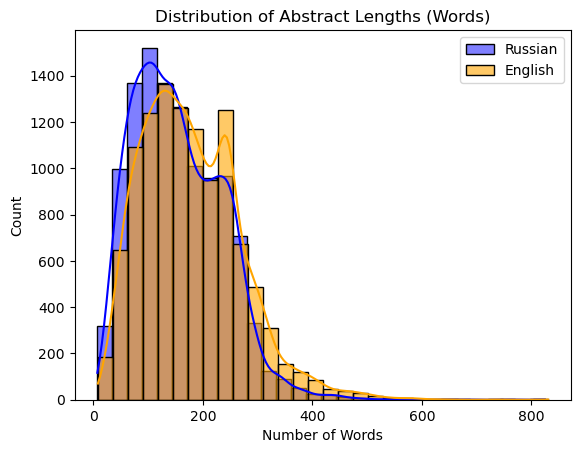

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/parallel_corpus.tsv", sep="\t", encoding="utf-8")

# Basic statistics
print(df.describe())
print(df.head())

# Plot text length distributions
df["Russian_Length"] = df["Russian"].apply(lambda x: len(x.split()))
df["English_Length"] = df["English"].apply(lambda x: len(x.split()))

sns.histplot(df["Russian_Length"], bins=30, kde=True, label="Russian", color="blue")
sns.histplot(df["English_Length"], bins=30, kde=True, label="English", color="orange", alpha=0.6)
plt.legend()
plt.title("Distribution of Abstract Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

Let's remove some of the 'misaligned' abstracts

In [2]:
!python3 scripts/clean_parallel_corpus.py --input data/parallel_corpus.tsv --output data/cleaned_parallel_corpus.tsv

Cleaned parallel corpus saved to data/cleaned_parallel_corpus.tsv


In [3]:
# Check the cleaned data
!head data/cleaned_parallel_corpus.tsv

Russian	English	Russian_Length	English_Length	Length_Ratio
Резюме Цель: Определить, в какой степени грипп способствует заражению лиц всех возрастов в Бангладеш тяжелой острой респираторной инфекцией (ТОРИ), которая является основной причиной детской смертности. Методы: Врачами были взяты мазки из носа и зева для анализа на вирус гриппа у пациентов, которые были госпитализированы в течение семи дней от начала заболевания тяжелой острой респираторной инфекцией (ТОРИ) или консультировались у врача в амбулаторном режиме по поводу гриппоподобной болезни (ГПБ). Было проведено исследование пользования медико-санитарной помощью на уровне общин для определения доли жителей участка, обслуживаемого больницей, которые обращались за помощью в обследуемые медицинские учреждения, и расчета заболеваемости гриппом с использованием указанного показателя в качестве знаменателя. Результаты: Оценочные показатели заболеваемости ТОРИ, коррелируемой с гриппом, у детей в возрасте до 5 лет, составили 6,7 (95% д

In [4]:
# Check tail also, just to be sure
!tail data/cleaned_parallel_corpus.tsv

Представлен обзор современных публикаций, посвященных функциональной магнитно-резонансной томографии (фМРТ), рассмотрены практические аспекты ее применения в нейрохирургии. Отмечены преимущества и недостатки методов, приведены результаты хирургического лечения пациентов с использованием функциональной нейронавигации. Отдельное внимание уделено оценке точности фМРТ, новому методу бесстимуляционной нейровизуализации. Приведены рекомендации применения фМРТ в нейроонкологии и хирургии артериовенозных мальформаций.	The study is a short review of articles concerning functional magnetic resonance imaging (fMRI) and its practical application in neurosurgery. Advantages and disadvantages of the methods are considered, the results of surgical treatment of patients using functional navigation are presented. Separate attention is paid to fMRI precision, a new resting-state method of visualization. Practical advices of fMRI application in neurooncology and surgery of arteriovenous malformations are

Some of the abstracts are quite long, we should split them into sentences before further tokenization.

In [5]:
!python3 scripts/split_abstracts.py --input data/cleaned_parallel_corpus.tsv --output data/sentence_aligned_corpus.tsv

Sentence-aligned corpus saved to data/sentence_aligned_corpus.tsv


## **2. Preprocessing: SentencePiece Tokenization**

- Extract source language data
- Train a SentencePiece model
- Tokenize the training and test sets

In [ ]:
import sentencepiece as spm

# Train SentencePiece. Output: spm_ru_only.model, spm_ru_only.vocab
!python3 scripts/sentencepiece_train.py

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: data/russian_sentences_corpus.tsv
  input_format: 
  model_prefix: models/spm_ru_only
  model_type: UNIGRAM
  vocab_size: 30000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable

In [13]:
!head -n20 models/spm_ru_only.vocab

<unk>	0
<s>	0
</s>	0
,	-3.29824
.	-3.35538
▁и	-3.64362
▁в	-3.89479
▁	-4.03527
▁с	-4.22979
ой	-4.37843
▁(	-4.49075
е	-4.56408
ого	-4.64274
-	-4.78956
х	-4.79569
▁на	-4.92243
а	-5.00571
й	-5.0104
)	-5.01237
и	-5.01419


In [ ]:
# Apply SentencePiece Tokenization
!python3 scripts/apply_sentencepiece.py --input data/parallel_corpus.tsv --output data/spm_parallel_corpus.tsv

SentencePiece tokenization complete. Processed 11152 sentences. Saved to data/spm_russian_sentences_corpus.tsv


In [10]:
!head -n 5 data/spm_parallel_corpus.tsv

Russian	English
▁Резюм е ▁Цель : ▁Определ ить , ▁в ▁как ой ▁степени ▁грипп ▁способству ет ▁заражени ю ▁лиц ▁всех ▁возраст ов ▁в ▁Б англ а де ш ▁тяжелой ▁острой ▁респираторн ой ▁инфекцией ▁( ТО РИ ), ▁которая ▁является ▁основной ▁причиной ▁детск ой ▁смертности . ▁Методы : ▁Врач ами ▁были ▁взяты ▁маз ки ▁из ▁носа ▁и ▁ з е ва ▁для ▁анализа ▁на ▁вирус ▁гриппа ▁у ▁пациентов , ▁которые ▁были ▁госпитализ ированы ▁в ▁течение ▁с е ми ▁дней ▁от ▁начала ▁заболевания ▁тяжелой ▁острой ▁респираторн ой ▁инфекцией ▁( ТО РИ ) ▁или ▁консультирова лись ▁у ▁врача ▁в ▁амбулаторн ом ▁режиме ▁по ▁по воду ▁грипп оподобн ой ▁болезни ▁( ГП Б ). ▁Был о ▁проведен о ▁исследование ▁пользова ния ▁медико - санитарн ой ▁помощью ▁на ▁уровне ▁общи н ▁для ▁определения ▁доли ▁жителей ▁участка , ▁об с лу жив а ем ого ▁больнице й , ▁которые ▁обраща лись ▁за ▁помощью ▁в ▁обследуем ые ▁медицинские ▁учреждения , ▁и ▁расчета ▁заболеваемости ▁грипп ом ▁с ▁использованием ▁указанн ого ▁показателя ▁в ▁качестве ▁ з на мена теля . ▁Р

## **3. Model Training**

- Train the sequence-to-sequence model
- Use label smoothing to improve training stability
- Save the trained model

In [ ]:
# Train the model
!python3 scripts/seq2seq_train.py

## **4. Translation & Evaluation**

- Translate test data
- Evaluate performance using BLEU and chrF

In [ ]:
# Translate test set
!python3 scripts/translate_wmt_test.py

In [ ]:
# Evaluate translations
!python3 scripts/evaluate_translations.py --hyp data/wmt_test_translations_with_beam.txt --ref data/test_reference_en.txt
print("Project setup complete! Ready for further analysis.")

## **5. Next Steps & Improvements**

- Compare GRU vs. LSTM architectures
- Improve handling of long sequences (segmenting abstracts)
- Fine-tune hyperparameters for better results